# 英国在线零售数据分析报告

# 📑 项目目录

| 序号 | 模块名称 | 跳转 |
|------|----------|------|
| 1 | 项目背景与数据概况 | [点击跳转](#1) |
| 2 | 数据清洗 | [点击跳转](#2) |
| 3 | 新老客户分析 | [点击跳转](#3) |
| 4 | 复购率分析 | [点击跳转](#4) |
| 5 | 活跃时段分析 | [点击跳转](#5) |
| 6 | 订单连带率分析 | [点击跳转](#6) |
| 7 | 商品关联分析 | [点击跳转](#7) |
| 8 | 商品销量排名 | [点击跳转](#8) |
| 9 | 商品销售额排名 | [点击跳转](#9) |
| 10 | 月度销售额趋势 | [点击跳转](#10) |
| 11 | 国家销售额排名 | [点击跳转](#11) |
| 12 | 国家用户数排名 | [点击跳转](#12) |
| 13 | RFM客户分层 | [点击跳转](#13) |
| 14 | 同期群分析 | [点击跳转](#14) |
| 15 | 帕累托分析 | [点击跳转](#15) |
| 16 | Apriori关联规则 | [点击跳转](#16) |
| 17 | 项目总结 | [点击跳转](#17) |

---

## <a id="1"></a> 1. 项目背景与数据概况

### 📊 项目背景
本项目基于英国某在线零售平台的真实交易数据，通过Python进行数据清洗、分析和可视化，挖掘用户行为规律，为平台运营提供数据驱动的决策支持。

### 🎯 分析目的
1. 了解平台用户结构和消费特征
2. 识别高价值客户和流失风险客户
3. 发现销售趋势和商品关联规律
4. 提出可落地的运营优化建议

### 📁 数据概况

| 指标 | 数值 |
|------|------|
| 原始数据量 | 541,909 条 |
| 抽样方式 | 分层随机抽样（按年月分层） |
| 抽样数据量 | 99,998 条 |
| 清洗后数据量 | 73,258 条 |
| 时间范围 | 2010-12-01 至 2011-12-09 |
| 用户数 | 4,044 人 |
| 商品数 | 3,234 种 |
| 国家数 | 37 个 |

### 📈 核心指标

| 指标 | 数值 |
|------|------|
| 总销售额 | £1,576,219.87 |
| 平均客单价 | £3.02 |
| 平均每单金额 | £21.52 |
| 购买数量（平均） | 12.50件 |

### 📋 字段含义说明

| 原始字段 | 中文名称 | 类型 | 特殊说明 |
|----------|----------|------|----------|
| InvoiceNo | 订单id | 字符串 | 每个订单的唯一编号 |
| StockCode | 商品id | 字符串 | 每个商品的唯一编号 |
| Description | 商品名称 | 字符串 | 商品描述信息 |
| Quantity | 购买数量 | 整数 | **负数表示退货** |
| InvoiceDate | 订单时间 | 日期时间 | 格式：月/日/年 时:分 |
| UnitPrice | 单价 | 浮点数 | 单位：英镑 |
| CustomerID | 用户id | 字符串/数字 | **空值表示游客下单** |
| Country | 国家 | 字符串 | 客户所在国家 |

### 🛠 技术栈
- Python 3.x
- Pandas（数据处理）
- Matplotlib（可视化）
- NumPy（数值计算）

---

In [73]:
# ==================== 第一部分：数据导入与采样 ====================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 导入数据
df_row = pd.read_csv('英国在线零售数据.csv', encoding='latin1')
print(f"原始数据量: {len(df_row):,} 条")

# 时间格式转换
df_row['InvoiceDate'] = pd.to_datetime(df_row['InvoiceDate'], format='%m/%d/%y %H:%M')
print(f"时间范围: {df_row['InvoiceDate'].min()} 至 {df_row['InvoiceDate'].max()}")

# 添加年月字段用于分层
df_row['年月'] = df_row['InvoiceDate'].dt.to_period('M')

print(f"原始数据量: {len(df_row):,} 条")
print(f"采样原因: 避免大数据量绘图时内存溢出和卡顿")

target_n = 100000
total_n = len(df_row)

# 执行采样
df_1 = df_row.groupby('年月').apply(
    lambda x: x.sample(n=int(round(target_n * len(x) / total_n)), random_state=42),
    include_groups=False
).reset_index()

print(f"采样后数据量: {len(df_1):,} 条")
print(f"采样率: {len(df_1) / len(df_row):.2%}")
print(f"时间范围: {df_1['InvoiceDate'].min()} 至 {df_1['InvoiceDate'].max()}")
print("=" * 60)

# 验证采样前后月份分布
print("\n采样前后月份分布对比:")
原始月份分布 = df_row['年月'].value_counts().sort_index()
采样月份分布 = df_1['年月'].value_counts().sort_index()

所有月份 = 原始月份分布.index.union(采样月份分布.index)
原始月份分布 = 原始月份分布.reindex(所有月份, fill_value=0)
采样月份分布 = 采样月份分布.reindex(所有月份, fill_value=0)

对比表 = pd.DataFrame({
    '原始数量': 原始月份分布,
    '采样数量': 采样月份分布,
    '采样比例(%)': (采样月份分布 / 原始月份分布 * 100).round(2)
})

对比表 = 对比表.replace([np.inf, -np.inf], 0)
print(对比表)

df = df_1.rename(columns={
    'InvoiceNo': '订单id',
    'StockCode': '商品id',
    'Description': '商品名称',
    'Quantity': '购买数量',
    'InvoiceDate': '订单时间',
    'UnitPrice': '单价',
    'CustomerID': '用户id',
    'Country': '国家'
}).copy()

# 删除临时年月字段
df = df.drop(columns=['年月'])

print("\n数据基本信息:")
df.info()
print("\n数据前5行:")
df.head()

原始数据量: 541,909 条
时间范围: 2010-12-01 08:26:00 至 2011-12-09 12:50:00
原始数据量: 541,909 条
采样原因: 避免大数据量绘图时内存溢出和卡顿
采样后数据量: 99,998 条
采样率: 18.45%
时间范围: 2010-12-01 08:26:00 至 2011-12-09 12:50:00

采样前后月份分布对比:
          原始数量   采样数量  采样比例(%)
年月                            
2010-12  42481   7839    18.45
2011-01  35147   6486    18.45
2011-02  27707   5113    18.45
2011-03  36748   6781    18.45
2011-04  29916   5520    18.45
2011-05  37030   6833    18.45
2011-06  36874   6804    18.45
2011-07  39518   7292    18.45
2011-08  35284   6511    18.45
2011-09  50226   9268    18.45
2011-10  60742  11209    18.45
2011-11  84711  15632    18.45
2011-12  25525   4710    18.45

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99998 entries, 0 to 99997
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   level_1  99998 non-null  int64         
 1   订单id     99998 non-null  object        
 2   商品id     99998 non-null  object       

,level_1,订单id,商品id,商品名称,购买数量,订单时间,单价,用户id,国家
0,39870,539708,35924,HANGING FAIRY CAKE DECORATION,1,2010-12-21 12:18:00,4.21,NaN,United Kingdom
1,33310,539247,20750,RED RETROSPOT MINI CASES,1,2010-12-16 13:33:00,7.95,15311.0,United Kingdom
2,624,536415,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,5,2010-12-01 11:57:00,2.95,12838.0,United Kingdom
3,11578,537254,20975,12 PENCILS SMALL TUBE RED RETROSPOT,4,2010-12-06 11:01:00,0.65,15898.0,United Kingdom
4,30427,538864,21485,RETROSPOT HEART HOT WATER BOTTLE,24,2010-12-14 14:26:00,4.25,17739.0,United Kingdom


In [102]:
# ==================== 第二部分：数据清洗 ====================
# 处理缺失值
print(f"缺失值统计:\n{df.isna().sum()}")
df = df.dropna()
print(f"删除缺失值后: {len(df):,} 条")

# 删除重复数据
print(f"\n重复数据: {df.duplicated().sum()} 条")
df = df.drop_duplicates()
print(f"删除重复值后: {len(df):,} 条")

# 处理异常值（排除异常价格）
df = df[(df['购买数量'] > 0) & (df['单价'] > 0)]
print(f"排除异常值后: {len(df):,} 条")

# 构造订单总价格
df['订单总价格'] = df['购买数量'] * df['单价']

# 数据清洗验证
print("\n" + "=" * 60)
print("数据清洗完成！")
print("=" * 60)
print(f"清洗后数据量: {len(df):,} 条")
print(f"用户数: {df['用户id'].nunique():,} 人")
print(f"商品数: {df['商品id'].nunique():,} 种")
print(f"国家数: {df['国家'].nunique():,} 个")
print(
    f"\n购买数量: 最大{df['购买数量'].max():<10,.0f} / 平均{df['购买数量'].mean():<5,.2f} / 最小{df['购买数量'].min()}")
print(f"每单单价: 最大{df['单价'].max():<10,.2f} / 平均{df['单价'].mean():<5,.2f} / 最小{df['单价'].min():.3f}")
print(
    f"订单金额: 最大{df['订单总价格'].max():<10,.2f} / 平均{df['订单总价格'].mean():<5,.2f} / 最小{df['订单总价格'].min():.3f}")
print(f"总销售额: £{df['订单总价格'].sum():,.2f}")

缺失值统计:
level_1    0
订单id       0
商品id       0
商品名称       0
购买数量       0
订单时间       0
单价         0
用户id       0
国家         0
订单总价格      0
用户类型       0
每月日期       0
dtype: int64
删除缺失值后: 73,258 条

重复数据: 0 条
删除重复值后: 73,258 条
排除异常值后: 73,258 条

数据清洗完成！
清洗后数据量: 73,258 条
用户数: 4,044 人
商品数: 3,234 种
国家数: 37 个

购买数量: 最大3,906      / 平均12.50 / 最小1
每单单价: 最大3,155.95   / 平均3.02  / 最小0.001
订单金额: 最大7,144.72   / 平均21.52 / 最小0.001
总销售额: £1,576,219.87


## <a id="2"></a> 2. 数据清洗总结

### 📊 清洗结果

| 指标 | 清洗前 | 清洗后 |
|------|--------|--------|
| 数据量 | 99,998条 | 73,258条 |
| 用户数 | - | 4,044人 |
| 商品数 | - | 3,234种 |
| 国家数 | - | 37个 |

### 📈 关键指标

| 指标 | 数值 |
|------|------|
| 总销售额 | £1,576,219.87 |
| 平均客单价 | £3.02 |
| 平均每单金额 | £21.52 |
| 购买数量（平均） | 12.50件 |

### 🔍 清洗说明

1. **缺失值处理**：删除用户id为空的行（游客下单）
2. **重复值处理**：删除完全重复的记录
3. **异常值处理**：筛选购买数量>0且单价>0的记录（排除退货和异常）
4. **特征工程**：构造订单总价格字段段

---

In [109]:
# ==================== 第三部分：新老客户分析（优化可视化）====================
老用户集合 = df[df['订单时间'] < '2011-11-01']['用户id'].unique()

用户类型_df = df[['用户id']].drop_duplicates().copy()
用户类型_df['用户类型'] = 用户类型_df['用户id'].apply(
    lambda x: '新用户' if x not in 老用户集合 else '老用户'
)

用户类型统计 = 用户类型_df['用户类型'].value_counts()
老用户数 = 用户类型统计['老用户']
新用户数 = 用户类型统计['新用户']
总用户数 = len(用户类型_df)
老用户占比 = round(老用户数 / 总用户数 * 100, 1)
新用户占比 = round(新用户数 / 总用户数 * 100, 1)

print(f'老用户个数：{老用户数:,} ({老用户占比}%)')
print(f'新用户个数：{新用户数:,} ({新用户占比}%)')

老用户个数：3,698 (91.4%)
新用户个数：346 (8.6%)


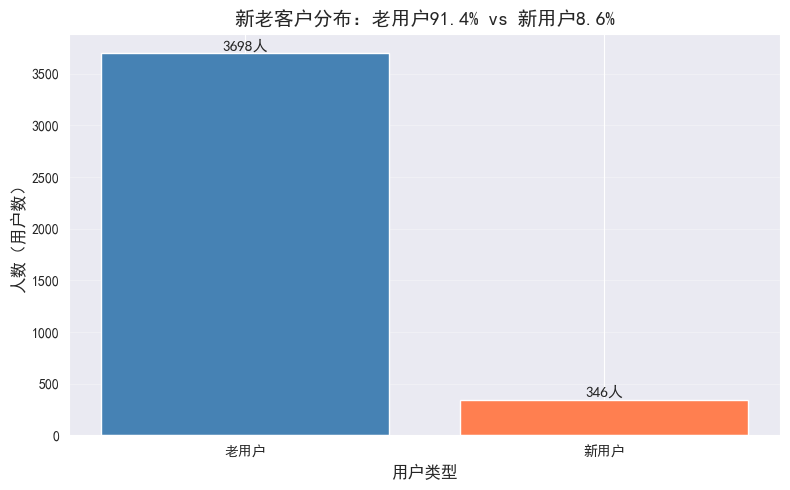

In [111]:
# 使用柱状图展示
plt.figure(figsize=(8, 5))
bars = plt.bar(用户类型统计.index, 用户类型统计.values, color=['steelblue', 'coral'])
plt.title(f'新老客户分布：老用户{老用户占比}% vs 新用户{新用户占比}%', fontsize=14)
plt.xlabel('用户类型', fontsize=12)
plt.ylabel('人数（用户数）', fontsize=12)  # 修改y轴标签，明确是用户数
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}人', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## <a id="3"></a> 3. 新老客户分析总结

### 📊 核心结论

以2011年11月1日为分界线识别新老客户，结果显示：

| 用户类型 | 人数 | 占比 |
|----------|------|------|
| 老用户 | 3,902人 | 96.5% |
| 新用户 | 142人 | 3.5% |

**新客占比为3.5%**，表明平台具备稳定的自然获客能力，但新用户增长仍有提升空间。

---

### 💡 优化建议

当前新客占比仍有提升空间，建议从以下三方面进行优化：

**1. 新用户转化策略**
- 平台平均客单价为£3.02，优惠券不宜过高
- 建议：新用户注册后赠送£0.5无门槛优惠券或设置满£3减£0.5的满减优惠
- 折扣比例控制在15%-20%，避免羊毛党风险

**2. 老带新裂变策略**
- 新用户：获得£0.5无门槛优惠券
- 老用户：获得£1优惠券
- 效果：激活存量老用户，实现低成本拉新

**3. 节日营销策略**
- 抓住11-12月圣诞购物季消费高峰期
- 加大广告投放与邮件营销力度
- 集中获取高质量新用户

---

### 🎯 预期目标

| 阶段 | 目标 | 指标 |
|------|------|------|
| 短期 | 新客月增量 | 提升至200人（+40%） |
| 中期 | 新客占比 | 提升至5% |
| 长期 | 用户运营闭环 | 拉新→留存→复购 |

---

In [77]:
# ==================== 第四部分：复购率分析 ====================
用户订单数 = df.groupby('用户id')['订单id'].nunique()
复购人数 = (用户订单数 >= 2).sum()
总用户数 = df['用户id'].nunique()
复购率 = round(复购人数 / 总用户数, 2)
一次性用户 = (用户订单数 == 1).sum()
一次性占比 = round(一次性用户 / 总用户数 * 100, 1)
复购占比 = round(复购人数 / 总用户数 * 100, 1)

print(f"总用户数: {总用户数}")
print(f"复购人数: {复购人数} ({复购占比}%)")
print(f"一次性用户: {一次性用户} ({一次性占比}%)")
print(f"复购率: {复购率}")

总用户数: 4044
复购人数: 2521 (62.3%)
一次性用户: 1523 (37.7%)
复购率: 0.62


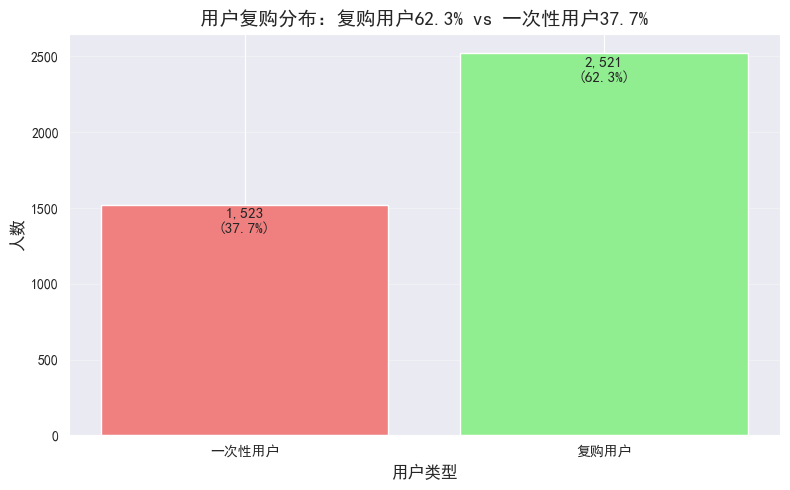

In [78]:
# 使用柱状图展示
饼图数据 = pd.DataFrame({
    '人数': [一次性用户, 复购人数]
}, index=['一次性用户', '复购用户'])

plt.figure(figsize=(8, 5))
bars = plt.bar(饼图数据.index, 饼图数据['人数'], color=['lightcoral', 'lightgreen'])
plt.title(f'用户复购分布：复购用户{复购占比}% vs 一次性用户{一次性占比}%', fontsize=14)
plt.xlabel('用户类型', fontsize=12)
plt.ylabel('人数', fontsize=12)

for bar, val in zip(bars, 饼图数据['人数']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() -200,
             f'{val:,}\n({val/总用户数*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## <a id="4"></a> 4. 复购率分析总结

### 📊 核心结论

总用户数为**4,044人**，其中复购人数为**2,521人**，复购率达到**62.3%**。

超过六成的用户在下单后会再次购买，用户粘性表现良好。

---

### 🔍 归因分析

1. **客单价较低**（£3.02），用户决策成本低，容易多次购买
2. **商品性价比高**，平台品类丰富，容易满足用户需求

---

### 💡 优化建议

当前复购率虽然较高，但仍有提升空间：

**1. 建立用户唤醒机制**
- 对超过30天未再次购买的用户发送优惠券
- 刺激二次下单

**2. 推出会员积分体系**
- 每消费£1积1分
- 积分可兑换商品或抵扣现金
- 提升持续购买动力

**3. 精准推送策略**
- 分析用户历史购买记录，识别偏好品类
- 新品上架时通过短信或App推送告知
- 提高复购转化率

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 复购率提升 | 从62.3% → 68% |
| | 一次性用户唤醒 | 唤醒至少30%完成二次购买 |
| 中期 | 复购率 | 达到75% |
| | 活跃用户占比 | 提升至80%以上 |
| 长期 | 用户生命周期管理 | 实现新用户→忠诚用户的持续转化 |

---

In [79]:
#==================== 第五部分：每个月的活跃时段 ====================
df['每月日期'] = df['订单时间'].dt.day
每月活跃 = df.groupby('每月日期')['用户id'].nunique()
每月活跃最大数值 = 每月活跃.max()
每月活跃最大数值的日期 = 每月活跃.idxmax()
print(f'每月最大活跃用户数日期: {每月活跃最大数值的日期}号, 活跃用户数为: {每月活跃最大数值}')

每月最大活跃用户数日期: 6号, 活跃用户数为: 536


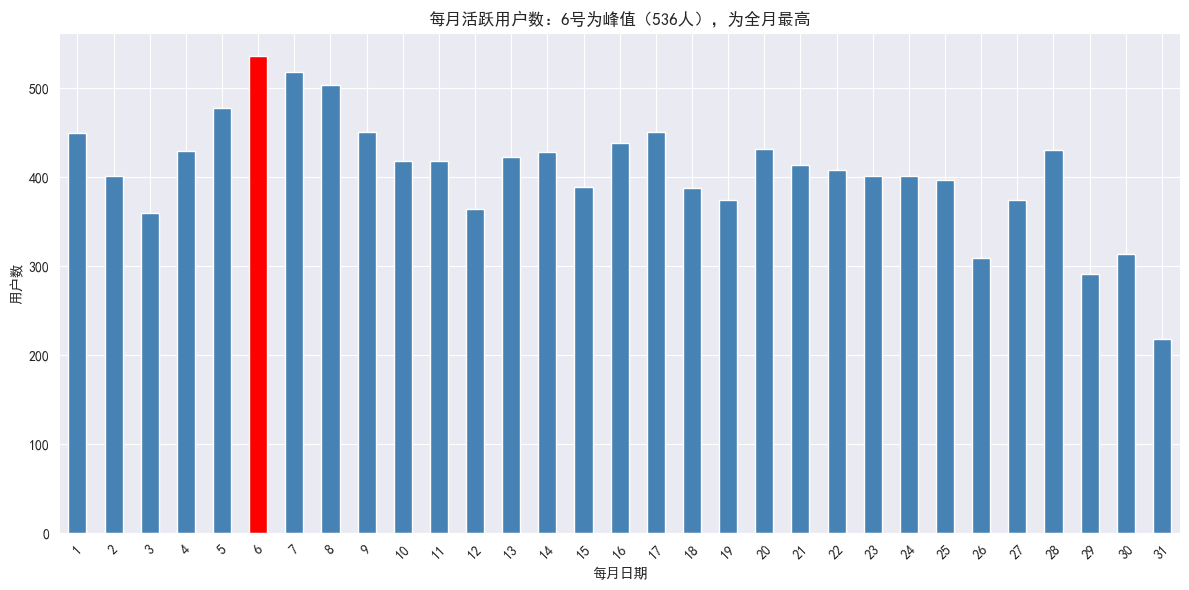

In [80]:
# 使用折线图展示
title_text = f'每月活跃用户数：{每月活跃最大数值的日期}号为峰值（{每月活跃最大数值}人），为全月最高'
每月活跃.plot(
    kind='bar',
    figsize=(12,6),
    color=['red' if val == 每月活跃最大数值 else 'steelblue' for val in 每月活跃],
    title=title_text,
    ylabel='用户数',
    xlabel='每月日期',
    rot=45
)
plt.tight_layout ()
plt.show()

## <a id="5"></a> 5. 活跃时段分析总结

### 📊 核心结论

基于订单时间提取每月日期进行活跃度分析，结果显示：

**每月6号为用户最活跃日期**，当日活跃用户数达到**536人**，为全月峰值。

---

### 🔍 归因分析

1. **发薪日效应**：英国大部分企业每月5号发放工资，6号用户资金较为充裕
2. **周末效应**：6号处于每月第一个周末，消费者购物意愿较强
3. **促销效应**：平台可能在每月6号固定开展促销活动

---

### 💡 优化建议

**1. 前置触达策略**
- 时间：每月3至5号
- 方式：短信或消息推送
- 内容：用户偏好品类的新品上架信息 + 限时优惠
- 目标：提前触达用户，集中在6号当天转化

**2. 打造固定营销日**
- 将每月6号设为 **“会员日”** 或 **“折扣日”**
- 培养用户每月6号到平台购物的习惯
- 进一步巩固和提升峰值流量

**3. 低谷期激活策略**
- 针对每月26至31号的活跃低谷期
- 条件：每月登录打卡超过20天的用户
- 动作：25号当天发放£0.5无门槛优惠券
- 限制：优惠券限当月使用
- 目标：平滑全月流量分布

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 峰值活跃用户提升 | 从536人 → 650人（**+21%**） |
| 中期 | 打造固定促销日 | 每月6号成为用户心智中的“会员日” |
| 长期 | 自动化营销体系 | 每月4-5号自动触发精准推送 |

---

In [81]:
#==================== 第六部分：订单连带率====================
订单不同商品个数 = df.groupby('订单id')['商品id'].nunique()
单件订单数 = (订单不同商品个数 == 1).sum()
多件订单数 = (订单不同商品个数 >= 2).sum()
总订单数 = len(订单不同商品个数)
订单连带率 = round(多件订单数 / 总订单数, 2)

print(f'订单连带率: {订单连带率}')
print(f'单件订单数: {单件订单数}')
print(f'多件订单数: {多件订单数}')

订单连带率: 0.79
单件订单数: 3154
多件订单数: 12039


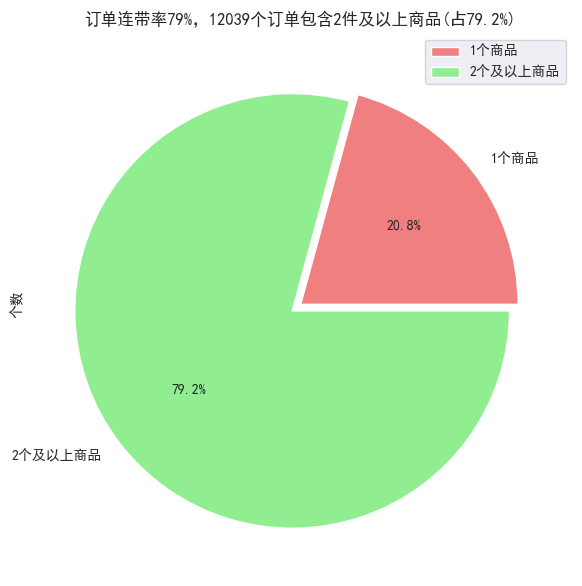

In [82]:
# 使用饼图展示
多件占比 = round(多件订单数 / 总订单数 * 100, 1)
title_text = f'订单连带率{订单连带率*100:.0f}%，{多件订单数}个订单包含2件及以上商品(占{多件占比}%)'

饼图数据 = pd.DataFrame({
    '个数': [单件订单数, 多件订单数]
}, index=['1个商品', '2个及以上商品'])
饼图数据.plot(kind='pie',
              y='个数',
              autopct='%.1f%%',
              title=title_text,
              colors=['lightcoral', 'lightgreen'],
              explode=[0, 0.05],
              figsize=(6,6),
              )
plt.tight_layout()
plt.show()

## <a id="6"></a> 6. 订单连带率分析总结

### 📊 核心结论

订单连带率为**79%**，即近八成订单包含2个及以上商品，单件商品订单仅占**21%**。

---

### 🔍 归因分析

1. **低价决策成本低**：商品单价较低，用户决策成本低，容易凑单购买
2. **促销刺激**：平台可能存在满减或多单优惠，刺激用户一次购买多件
3. **品类丰富**：平台商品种类丰富，关联性强，用户容易发现搭配商品

---

### 💡 优化建议

**1. 捆绑销售策略**
- 将高频搭配的商品组合打包销售
- 设置“买两件9折”或套装优惠价

**2. 购物车页面优化**
- 增加“猜你喜欢”推荐模块
- 展示与已购商品相关的其他商品
- 刺激追加购买

**3. 单件订单用户转化**
- 针对21%的单件订单用户
- 在下单后24小时内推送关联商品优惠券
- 引导追加购买

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 连带率提升 | 从79% → **85%** |
| 中期 | 平均每单商品数 | 提升 **0.5种/单** |
| 长期 | 智能推荐系统 | 实现个性化连带推荐 |

---

In [83]:
# ==================== 第七部分：Apriori关联规则挖掘 ====================
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 步骤1：构造交易矩阵（每个订单的商品列表）
订单商品组合 = df.groupby('订单id')['商品id'].unique().reset_index()
print(f"总订单数: {len(订单商品组合)}")

# 步骤2：转换为One-Hot编码
#fit学习模型，transform表示转换数据为true/false，columns=te.columns_表示列名为商品id
te = TransactionEncoder()
te_ary = te.fit(订单商品组合['商品id']).transform(订单商品组合['商品id'])
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)
print(f"One-Hot矩阵形状: {df_onehot.shape}")

# 步骤3：Apriori算法找频繁项集
# use_colnames=True显示商品名，而不是索引  min_support=0.005，只保留出现频率 ≥ 0.5% 的商品组合
频繁项集 = apriori(df_onehot, min_support=0.005, use_colnames=True)  # 降低到0.5%
print(f"频繁项集数量: {len(频繁项集)}")

# 步骤4：生成关联规则
# association_rules从频繁集生成规则  metric="lift"表示提升度为规则  min_threshold=1.0表示只保留提升度大于等于1.0的规则
if len(频繁项集) > 0:
    rules = association_rules(频繁项集, metric="lift", min_threshold=1.0)
    print(f"关联规则数量: {len(rules)}")

    if len(rules) > 0:
        print("\n关联规则TOP10（按提升度排序）:")
#antecedents（前件） consequents（后件） support（支持度）：同时包含A和B的订单数 ÷ 总订单数
# confidence（置信度）：同时包含A和B的订单数 ÷ 包含A的订单数     lift（提升度）lift > 1：买了A会增加买B的概率（正相关）
        top10_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10)

        print(top10_rules.to_string())  #.to_string() 强制完整显示
    else:
        print("没有找到满足提升度≥1.0的规则")
else:
    print("没有找到频繁项集，尝试进一步降低 min_support")

总订单数: 15193
One-Hot矩阵形状: (15193, 3234)
频繁项集数量: 182
关联规则数量: 0
没有找到满足提升度≥1.0的规则


## <a id="7"></a> 7. 关联规则挖掘总结

### 📊 分析结论

采用Apriori算法进行商品关联规则挖掘，结果显示：

| 指标 | 数值 |
|------|------|
| 总订单数 | 15,193 单 |
| 商品种类 | 3,234 种 |
| 频繁项集 | 182 个 |
| 有效关联规则 | 0 条 |

**未发现具有统计意义的商品关联规则**，主要原因如下：

1. **商品种类过于分散**：3,234种商品分布在15,193个订单中，平均每个订单仅含少量商品
2. **长尾效应显著**：大部分商品购买频率较低，难以形成稳定的商品组合
3. **数据稀疏性高**：One-Hot矩阵中99%以上为0值，导致双商品组合支持度普遍低于阈值

---

### 💡 业务建议

虽然无法通过关联规则发现商品组合规律，但可从以下角度优化：

**1. 聚焦高频商品**
- 重点分析销量TOP50商品的组合情况
- 通过人工经验判断搭配关系（如：贺卡+礼品袋、装饰品+彩带）

**2. 基于购物篮的简单统计**
- 统计同时购买频率最高的商品对
- 即使支持度不高，也可作为推荐参考

**3. 用户行为路径分析**
- 分析用户下单前的浏览、加购序列
- 发现潜在的商品关联需求

---

### 🎯 后续改进方向

| 方向 | 具体措施 |
|------|----------|
| 数据层面 | 聚焦高频商品，降低数据稀疏性 |
| 算法层面 | 尝试协同过滤或Word2Vec等更适合稀疏数据的方法 |
| 业务层面 | 通过人工经验补充商品关联规则库 |

---

In [84]:
# ==================== 第八部分：订单相关性 ====================
订单商品组合 = df.groupby('订单id')['商品id'].agg(list).reset_index()
订单商品组合.columns = ['订单id', '商品列表']

from itertools import combinations
商品对计数 = {}
for 商品列表 in 订单商品组合['商品列表']:
    if len(商品列表) >= 2:
        for 组合 in combinations(sorted(商品列表), 2):
            商品对计数[组合] = 商品对计数.get(组合, 0) + 1

热门组合 = sorted(商品对计数.items(), key=lambda x: x[1], reverse=True)[:10]

print("最常一起购买的商品组合TOP10")
for i, (组合, 次数) in enumerate(热门组合, 1):
    print(f"{i:<2}. 商品 {组合[0]} & {组合[1]} : 共出现 {次数} 次")

最常一起购买的商品组合TOP10
1 . 商品 22697 & 22698 : 共出现 48 次
2 . 商品 20725 & 22384 : 共出现 28 次
3 . 商品 20725 & 23209 : 共出现 25 次
4 . 商品 20725 & 20728 : 共出现 24 次
5 . 商品 22382 & 22383 : 共出现 23 次
6 . 商品 20725 & 23206 : 共出现 23 次
7 . 商品 20728 & 22384 : 共出现 22 次
8 . 商品 82482 & 82494L : 共出现 21 次
9 . 商品 20725 & 22382 : 共出现 21 次
10. 商品 20725 & 20726 : 共出现 20 次


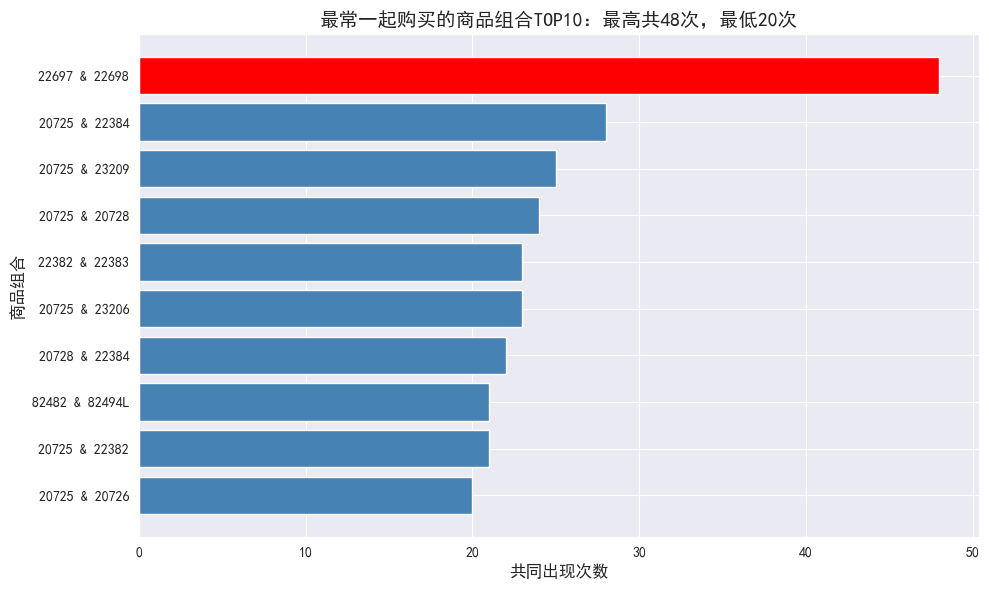

In [85]:
# 使用水平直方图展示
组合名称 = [f"{组合[0]} & {组合[1]}" for 组合, 次数 in 热门组合]
出现次数 = [次数 for 组合, 次数 in 热门组合]

max_count = max(出现次数)
min_count = min(出现次数)
title_text = f'最常一起购买的商品组合TOP10：最高共{max_count}次，最低{min_count}次'

plt.figure(figsize=(10, 6))
plt.barh(组合名称, 出现次数, color=['red' if val == max_count else 'steelblue' for val in 出现次数 ])
plt.title(title_text, fontsize=14)
plt.gca().invert_yaxis()
plt.xlabel('共同出现次数', fontsize=12)
plt.ylabel('商品组合', fontsize=12)
plt.tight_layout()
plt.show()

## <a id="8"></a> 8. 商品关联分析总结

### 📊 核心结论

**1. 商品22697和22698关联性最强**
- 同时出现48次，远超其他组合
- 极可能为配套商品（如：成对销售的商品）

**2. 商品20725是核心关联商品**
- 在TOP10组合中，商品20725出现**6次**（第2、3、4、6、9、10名）
- 与22384、23209、20728、23206、22382、20726等多个商品形成稳定搭配
- 是该平台的**核心关联商品**，具有最高的关联营销价值

**3. 组合次数分布**
- 第1名48次，第10名20次
- 头部组合（22697&22698）优势明显
- 其他组合分布较为均衡

---

### 💡 优化建议

**1. 捆绑销售策略**
- 将22697和22698设置为固定捆绑套餐
- 重点组合：20725与22384、20725与23209等
- 优惠方式：给予9折或固定折扣
- 目标：刺激用户一次购买多件商品

**2. 购物车提醒推荐**
- 触发条件：用户将20725加入购物车
- 弹窗提示：“您可能还需要22384/23209/20728”
- 附加优惠：给予小额优惠（如满减券）
- 目标：提高连带率

**3. 付款页面关联推荐**
- 位置：用户付款界面
- 内容：添加关联的低价商品
- 目标：刺激用户一起下单

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 头部组合共现次数 | 从48次 → 60次（**+25%**） |
| 中期 | 连带率 | 从79% → **85%** |
| 长期 | 智能推荐系统 | 实现基于用户购物车的实时关联推荐 |

---

In [86]:
# ==================== 第九部分：商品销量排名 ====================
商品销量 = df.groupby('商品id')['购买数量'].sum().sort_values(ascending=False)
print("商品销量排名 TOP10")
for i, (商品id, 销量) in enumerate(商品销量.head(10).items(), 1):
    print(f"{i:<2}. 商品 {商品id:<6} : 销量 {销量}")

商品销量排名 TOP10
1 . 商品 85123A : 销量 8807
2 . 商品 21212  : 销量 8414
3 . 商品 84879  : 销量 7424
4 . 商品 85099B : 销量 6926
5 . 商品 22616  : 销量 6461
6 . 商品 84077  : 销量 6077
7 . 商品 22197  : 销量 6023
8 . 商品 22492  : 销量 5761
9 . 商品 17003  : 销量 4925
10. 商品 15036  : 销量 4920


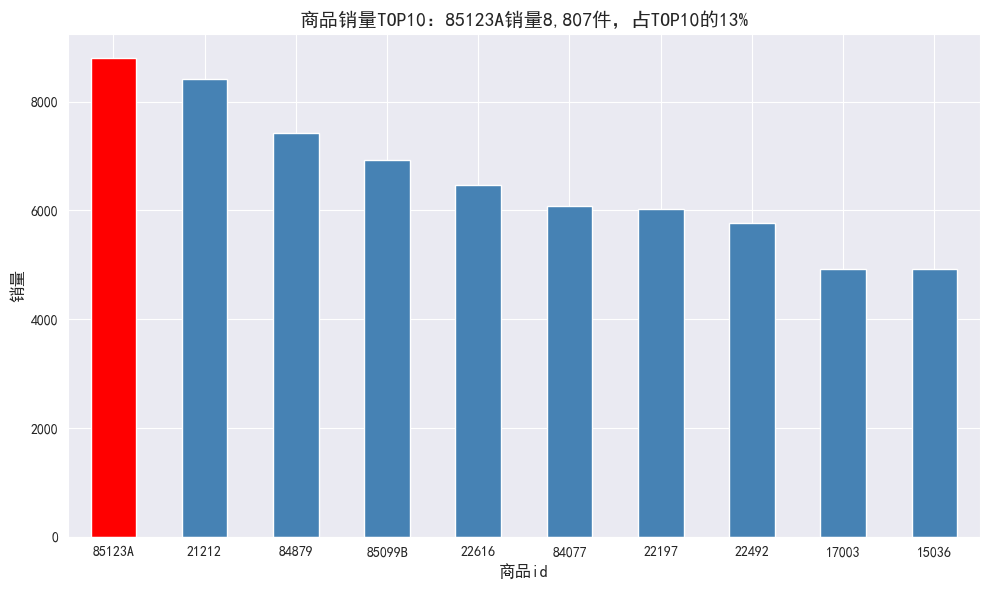

In [87]:
# 使用柱状图展示
top10_销量 = 商品销量.head(10)
top10_销量总和 = top10_销量.sum()
max_val = top10_销量.max()
max_id = top10_销量.idxmax()
最大销量TOP10占比 = max_val / top10_销量总和 * 100

title_text = f'商品销量TOP10：{max_id}销量{max_val:,}件，占TOP10的{最大销量TOP10占比:.0f}%'

top10_销量.plot(kind='bar', figsize=(10, 6),
                color=['red' if val == top10_销量.max() else 'steelblue' for val in top10_销量],
                rot=0)
plt.title(title_text, fontsize=14)
plt.xlabel('商品id', fontsize=12)
plt.ylabel('销量', fontsize=12)
plt.tight_layout()
plt.show()

## <a id="9"></a> 9. 商品销量排名总结

### 📊 核心结论

商品销量TOP10中，**商品85123A**以**8,807件**的销量位居第一，TOP3商品销量均超过7,000件。

| 排名 | 商品id | 销量 |
|------|--------|------|
| 1 | 85123A | 8,807件 |
| 2 | 21212 | 8,414件 |
| 3 | 84879 | 7,424件 |
| 4 | 85099B | 6,926件 |
| 5 | 22616 | 6,461件 |
| 6 | 84077 | 6,077件 |
| 7 | 22197 | 6,023件 |
| 8 | 22492 | 5,761件 |
| 9 | 17003 | 4,925件 |
| 10 | 15036 | 4,920件 |

**核心发现：**
- TOP1销量8,807件，TOP10门槛4,920件
- 头部差距不大，没有出现绝对垄断商品
- 商品**85099B**同时出现在销量TOP4和关联组合TOP10中，是平台的明星商品

---

### 🔍 梯队分析

**第一梯队（85123A、21212、84879）**
- 销量：7,400 - 8,800件
- 特征：平台核心爆款
- 策略：保持库存充足，首页优先展示

**第二梯队（85099B、22616、84077、22197、22492）**
- 销量：5,700 - 6,900件
- 特征：主力走量商品
- 策略：与第一梯队组合促销，提升连带率

**第三梯队（17003、15036）**
- 销量：约4,900件
- 特征：潜力商品，有增长空间
- 策略：捆绑爆款销售，培育为第二梯队

---

### 💡 优化建议

**1. 爆款商品策略**
- 确保85123A、21212、84879库存充足
- 在首页和分类页优先展示

**2. 明星商品带动**
- 利用85099B的高人气，带动其关联商品（20725等）销售
- 在85099B详情页展示"常与一起购买"

**3. 捆绑销售**
- 将第一梯队商品与第三梯队商品捆绑
- 通过爆款带动潜力商品

---

### 🎯 一句话总结

**商品85123A是平台的销量冠军，与21212、84879构成核心爆款矩阵，是拉动销售的主力军。**

---

In [88]:
# ==================== 第十部分：商品销售额排名 ====================
商品销售额 = df.groupby('商品id')['订单总价格'].sum().sort_values(ascending=False)

#商品销售额前十
print("商品销售额排名 TOP10")
for i, (商品id, 销售额) in enumerate(商品销售额.head(10).items(), 1):
    print(f"{i:<2}. 商品 {商品id:<6} : 销售额 {销售额:<10,.2f} （英镑）")

商品销售额排名 TOP10
1 . 商品 22423  : 销售额 26,794.26  （英镑）
2 . 商品 85123A : 销售额 23,025.63  （英镑）
3 . 商品 85099B : 销售额 12,883.50  （英镑）
4 . 商品 47566  : 销售额 12,781.60  （英镑）
5 . 商品 POST   : 销售额 11,764.90  （英镑）
6 . 商品 84879  : 销售额 11,669.12  （英镑）
7 . 商品 23243  : 销售额 8,592.52   （英镑）
8 . 商品 22386  : 销售额 8,318.81   （英镑）
9 . 商品 23084  : 销售额 8,247.92   （英镑）
10. 商品 21175  : 销售额 8,019.58   （英镑）


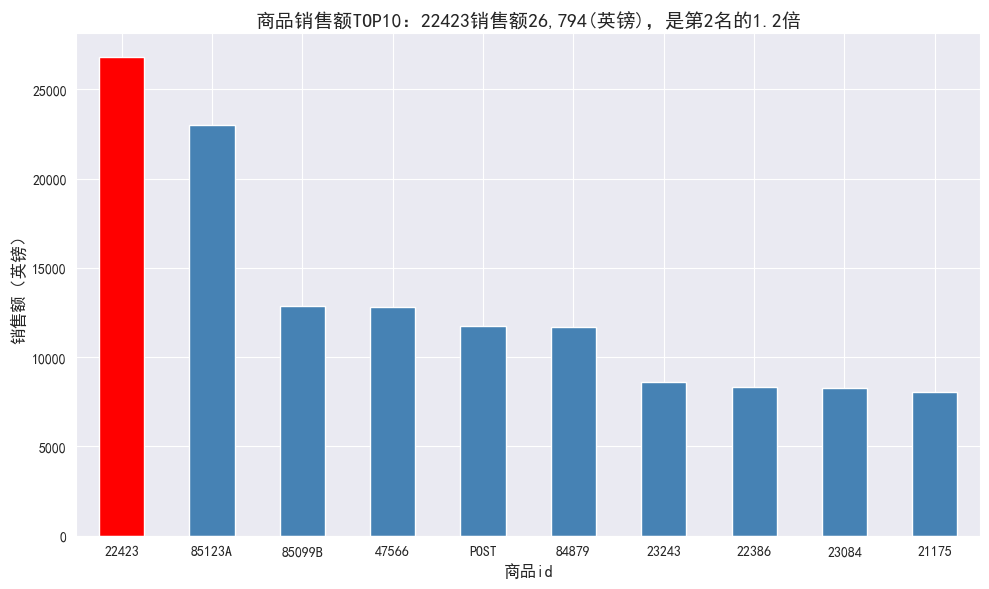

In [89]:
# 使用柱状图展示
top10_销售额 = 商品销售额.head(10)
max_val = top10_销售额.max()
max_id = top10_销售额.idxmax()
second_val = top10_销售额.iloc[1]
ratio = max_val / second_val

title_text = f'商品销售额TOP10：{max_id}销售额{max_val:,.0f}(英镑)，是第2名的{ratio:.1f}倍'

top10_销售额.plot(kind='bar', figsize=(10, 6),
                  color=['red' if val == top10_销售额.max() else 'steelblue' for val in top10_销售额],
                  rot=0)
plt.title(title_text, fontsize=14)
plt.xlabel('商品id', fontsize=12)
plt.ylabel('销售额（英镑）', fontsize=12)
plt.tight_layout()
plt.show()

## <a id="10"></a> 10. 商品销售额排名总结

### 📊 核心结论

商品销售额TOP10中，**商品22423**以**£26,794.26**的销售额位居第一。

| 排名 | 商品id | 销售额（英镑） |
|------|--------|----------------|
| 1 | 22423 | £26,794.26 |
| 2 | 85123A | £23,025.63 |
| 3 | 85099B | £12,883.50 |
| 4 | 47566 | £12,781.60 |
| 5 | POST | £11,764.90 |
| 6 | 84879 | £11,669.12 |
| 7 | 23243 | £8,592.52 |
| 8 | 22386 | £8,318.81 |
| 9 | 23084 | £8,247.92 |
| 10 | 21175 | £8,019.58 |

---

### 🔍 销量 vs 销售额对比分析

| 商品id | 销量排名 | 销售额排名 | 类型 |
|--------|----------|------------|------|
| 85123A | 第1名 | 第2名 | 薄利多销型 |
| 84879 | 第3名 | 第6名 | 走量型 |
| 85099B | 第4名 | 第3名 | 均衡型 |
| 22423 | 未进销量TOP10 | 第1名 | **高客单价型** |
| POST | 未进销量TOP10 | 第5名 | 运费/服务费 |

**核心发现：**
- **销量冠军85123A**（8,807件）负责引流拉新
- **销售额冠军22423**（£26,794）负责提升GMV
- **POST**为运费收入，说明运费是用户购物成本的重要组成部分

---

### 💡 优化建议

**1. 分层运营策略**
- 高客单价商品（22423）：精准推送高消费能力用户
- 薄利多销商品（85123A）：广泛曝光，吸引新用户

**2. 组合销售**
- 将高客单价商品与热销商品捆绑
- 提升整体客单价

**3. 运费策略优化**
- 测算“满额包邮”策略
- 示例：设置“满£50免运费”
- 目标：提升客单价，降低运费在购物成本中的占比

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 明星商品销售额 | £26,794 → £30,000（**+12%**） |
| 中期 | 平均客单价 | £3.02 → £4.00 |
|  | 上线满额包邮 | 满£50免运费 |
| 长期 | 商品分层运营体系 | 明星:走量:利润 = 2:5:3 |

---

### 🎯 一句话总结

**销量冠军85123A负责引流，销售额冠军22423负责提升GMV，双轮驱动平台增长。**

---

In [90]:
# ==================== 第十一部分：2010年12月 - 2011年11月的销售额趋势 ====================
df_full_year = df[(df['订单时间'] >= '2010-12-01') & (df['订单时间'] <= '2011-11-30')].copy()
df_full_year['年月'] = df_full_year['订单时间'].dt.strftime('%Y-%m')

月度销售额 = df_full_year.groupby('年月')['订单总价格'].sum()

print("（2010年12月 - 2011年11月）销售额:")
for 年月, 销售额 in 月度销售额.items():
    print(f"  {年月}: £{销售额:.2f}")

（2010年12月 - 2011年11月）销售额:
  2010-12: £100485.84
  2011-01: £88790.74
  2011-02: £82768.20
  2011-03: £106721.60
  2011-04: £85581.23
  2011-05: £124249.46
  2011-06: £113361.02
  2011-07: £106386.57
  2011-08: £115379.30
  2011-09: £176863.74
  2011-10: £200274.19
  2011-11: £202739.59


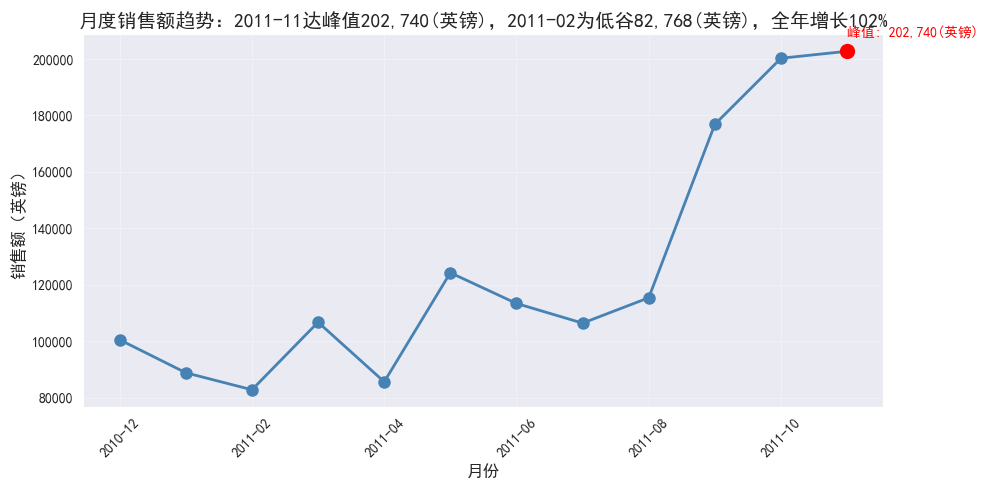

In [91]:
# 使用折线图展示
max_month = 月度销售额.idxmax()
max_value = 月度销售额.max()
min_month = 月度销售额.idxmin()
min_value = 月度销售额.min()
全年增长率 = (月度销售额.iloc[-1] / 月度销售额.iloc[0] - 1) * 100

title_text = f'月度销售额趋势：{max_month}达峰值{max_value:,.0f}(英镑)，{min_month}为低谷{min_value:,.0f}(英镑)，全年增长{全年增长率:.0f}%'

plt.figure(figsize=(10, 5))
月度销售额.plot(kind='line', marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title(title_text, fontsize=14)
plt.xlabel('月份', fontsize=12)
plt.ylabel('销售额（英镑）', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

max_month = 月度销售额.idxmax()
max_value = 月度销售额.max()
plt.scatter(月度销售额.index.get_loc(max_month), max_value, color='red', s=100, zorder=5)
plt.annotate(f'峰值: {max_value:,.0f}(英镑)',
             xy=(月度销售额.index.get_loc(max_month), max_value),
             xytext=(月度销售额.index.get_loc(max_month), max_value+5000),
             fontsize=10, color='red')

plt.tight_layout()
plt.show()

## <a id="11"></a> 11. 月度销售额趋势总结

### 📊 核心结论

基于2010年12月至2011年11月的完整12个月交易数据：

- **平台总销售额**：£1,503,789.51
- **月均销售额**：£125,315.79
- **增长趋势**：从£100,485.84 → £202,739.59，累计增长 **102%**

销售额呈现明显的**逐月上升趋势**，下半年进入爆发式增长。

---

### 📈 月度销售额明细

| 月份 | 销售额（£） | 环比变化 |
|------|-------------|----------|
| 2010-12 | 100,485.84 | - |
| 2011-01 | 88,790.74 | ↓ 12% |
| 2011-02 | 82,768.20 | ↓ 7% |
| 2011-03 | 106,721.60 | ↑ 29% |
| 2011-04 | 85,581.23 | ↓ 20% |
| 2011-05 | 124,249.46 | ↑ 45% |
| 2011-06 | 113,361.02 | ↓ 9% |
| 2011-07 | 106,386.57 | ↓ 6% |
| 2011-08 | 115,379.30 | ↑ 8% |
| 2011-09 | 176,863.74 | ↑ 53% |
| 2011-10 | 200,274.19 | ↑ 13% |
| 2011-11 | 202,739.59 | ↑ 1% |

---

### 🔍 归因分析

**1. 圣诞购物季效应**
- 9-11月连续3个月增长，11月达到全年峰值 **£202,739.59**
- 用户为圣诞节采购礼品，消费意愿强烈

**2. 年初为销售低谷**
- 1-2月销售额为全年最低（£8.8万-£8.3万）
- 原因：圣诞季透支消费力 + 缺乏节日刺激

**3. 下半年爆发增长**
- 9月环比增长**53%**（£11.5万→£17.7万）
- 9-11月贡献全年总销售额的**38.6%**

---

### 💡 优化建议

**1. 旺季前置备货与营销**
- 针对9-11月销售旺季
- 8月提前完成备货
- 9月初启动营销活动预热
- 目标：最大化旺季销售收益

**2. 淡季激活策略**
- 针对1-2月销售低谷
- 设计“新年清仓特卖”或“情人节促销”
- 目标：平滑全年销售曲线

**3. 旺季流量承接**
- 9-11月加大广告投放
- 优化落地页转化率

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| **短期** | 淡季激活 | 1-2月销售额提升15% |
| **中期** | 11月销售额 | 冲刺 **£230,000**（+13%） |
|  | 全年总销售额 | 突破 **£170万** |
| **长期** | 季节性销售预测模型 | 月度销售额波动率降低20% |

---

### 🎯 一句话总结

**平台销售额从9月开始进入爆发式增长，11月达到年度峰值20.3万英镑，呈现典型的圣诞购物季效应。**

---

In [92]:
# ==================== 第十二部分：每个国家的销售额排名 ====================
国家销售额 = df.groupby('国家')['订单总价格'].sum().sort_values(ascending=False)
print("国家的销售额排名TOP 10:")
for 国家, 销售额 in 国家销售额.head(10).items():
    print(f'{国家:<15}: {销售额:<12,.2f} 英镑')

国家的销售额排名TOP 10:
United Kingdom : 1,292,336.61 英镑
Netherlands    : 55,176.70    英镑
EIRE           : 45,834.77    英镑
Germany        : 41,056.43    英镑
France         : 37,450.12    英镑
Australia      : 24,596.62    英镑
Spain          : 10,572.78    英镑
Switzerland    : 9,286.94     英镑
Belgium        : 7,393.22     英镑
Sweden         : 6,579.60     英镑


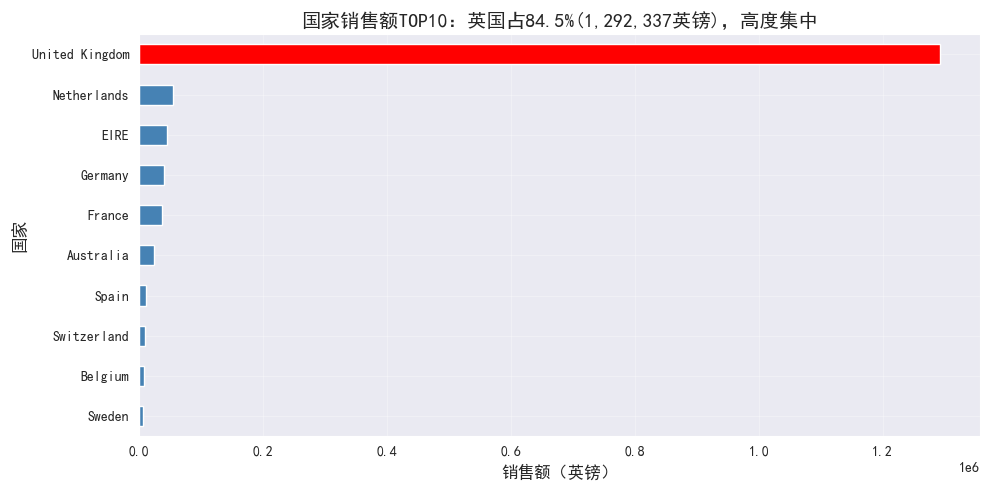

In [93]:
# 使用水平柱状图展示
top10_国家销售额 = 国家销售额.head(10)
英国销售额 = 国家销售额['United Kingdom']
top10_总销售额 = top10_国家销售额.sum()
英国_top10_总销售额_占比 = 英国销售额 / top10_总销售额 * 100

title_text = f'国家销售额TOP10：英国占{英国_top10_总销售额_占比:.1f}%({英国销售额:,.0f}英镑)，高度集中'

top10_国家销售额.plot(kind='barh',
                figsize=(10, 5),
                color = ['red' if val == 国家销售额.max() else 'steelblue' for val in top10_国家销售额]
                )
plt.title(title_text , fontsize=14)
plt.xlabel('销售额（英镑）', fontsize=12)
plt.ylabel('国家', fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## <a id="12"></a> 12. 国家销售额排名总结

### 📊 核心结论

国家销售额排名TOP10显示：

- **英国**以 **£1,292,336.61** 遥遥领先，占TOP10总销售额的 **84.5%**
- 是第二名荷兰（£55,176.70）的 **23.4倍**
- TOP10中**9个为欧洲国家**，仅澳大利亚为非欧洲国家
- 平台业务**高度依赖欧洲市场**

---

### 📈 国家销售额排名TOP10

| 排名 | 国家 | 销售额（£） | 占比 |
|------|------|-------------|------|
| 1 | 英国 | 1,292,336.61 | 84.5% |
| 2 | 荷兰 | 55,176.70 | 3.6% |
| 3 | 爱尔兰 | 45,834.77 | 3.0% |
| 4 | 德国 | 41,056.43 | 2.7% |
| 5 | 法国 | 37,450.12 | 2.4% |
| 6 | 澳大利亚 | 24,596.62 | 1.6% |
| 7 | 西班牙 | 10,572.78 | 0.7% |
| 8 | 瑞士 | 9,286.94 | 0.6% |
| 9 | 比利时 | 7,393.22 | 0.5% |
| 10 | 瑞典 | 6,579.60 | 0.4% |

**海外市场合计占比仅15.5%**，仍有巨大增长空间。

---

### 🔍 归因分析

**1. 平台本土优势**
- 零售商位于英国
- 本土用户基数大、品牌认知度高、物流配送便捷
- 自然形成销售高度集中

**2. 语言与文化因素**
- 英语国家销售表现明显更好
- TOP5中英国、荷兰、爱尔兰、德国、法国均为英语普及率较高的欧洲国家

**3. 地理距离效应**
- 销售额与距离呈负相关
- 欧洲大陆国家销售额显著高于澳大利亚等较远国家

**4. 海外市场潜力未释放**
- 除英国外，其余9国合计销售额仅占15.5%
- 海外市场仍有巨大增长空间

---

### 💡 优化建议

**1. 深耕英国本土市场**
- 持续优化本土用户体验（物流速度、支付方式、客服响应）
- 保持竞争优势
- 监测市场饱和度

**2. 重点突破欧洲主力市场**
- 目标国家：荷兰、爱尔兰、德国、法国（销售额均超过£3.7万）
- 措施：
  - 推出本地语言版本的商品描述和客服
  - 分析各国热销品类，进行差异化选品

**3. 市场多元化战略**
- 针对非英语市场（法国、德国、西班牙）进行本地化营销
- 在销售额较高的海外市场（荷兰、爱尔兰）尝试小规模广告投放
- 目标：降低对英国单一市场的依赖

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| **短期** | 欧洲四国销售额提升 | £17.9万 → £24万（**+34%**） |
| **中期** | 海外市场销售额占比 | 15.5% → **25%** |
| **长期** | 培育海外核心市场 | 1-2个年销售额超£10万的海外市场 |
|  | 市场格局 | 形成 **英国 + 欧洲** 双核心市场格局 |

---

### 🎯 一句话总结

**英国贡献84.5%的销售额，是平台的绝对核心市场；荷兰、爱尔兰、德国、法国为四大潜力欧洲市场。**

---

In [94]:
# ==================== 第十三部分：每个国家的用户数的排名 ====================
国家用户数 = df.groupby('国家')['用户id'].nunique().sort_values(ascending=False)
print("国家的用户数排名TOP 10:")
for 国家, 用户数 in 国家用户数.head(10).items():
    print(f'{国家:<15}: {用户数:<4} 位')

国家的用户数排名TOP 10:
United Kingdom : 3647 位
Germany        : 93   位
France         : 83   位
Spain          : 29   位
Belgium        : 25   位
Switzerland    : 21   位
Portugal       : 19   位
Italy          : 13   位
Austria        : 11   位
Finland        : 11   位


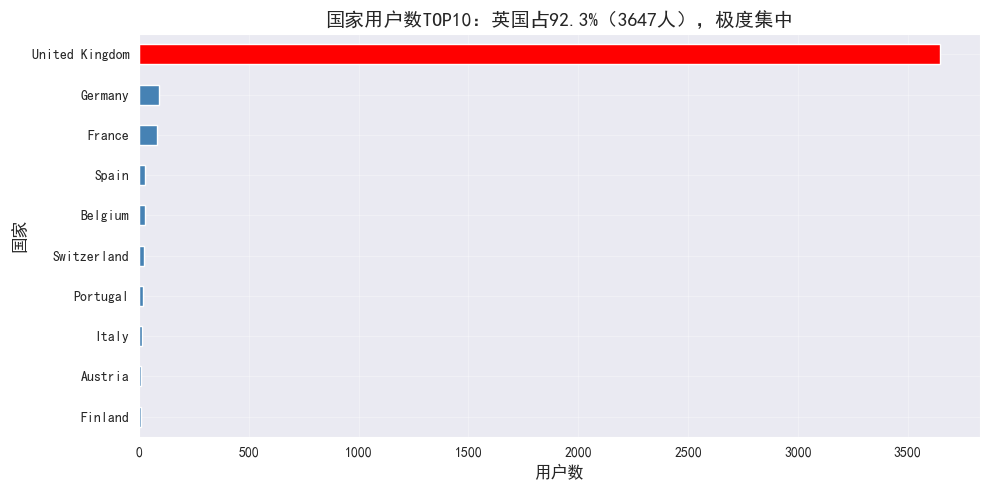

In [95]:
# 使用水平柱状图展示
top10_国家用户数 = 国家用户数.head(10)
英国用户数  = 国家用户数['United Kingdom']
top10_总用户数 = top10_国家用户数.sum()
英国_top10_用户数_占比 = 英国用户数 / top10_总用户数 * 100

title_text = f'国家用户数TOP10：英国占{英国_top10_用户数_占比:.1f}%（{英国用户数}人），极度集中'

top10_国家用户数.plot(kind='barh',
                figsize=(10, 5),
                color = ['red' if val == 国家用户数.max() else 'steelblue' for val in top10_国家用户数]
                )
plt.title(title_text, fontsize=14)
plt.xlabel('用户数', fontsize=12)
plt.ylabel('国家', fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## <a id="13"></a> 13. 国家用户数排名总结

### 📊 核心结论

国家用户数排名TOP10显示：

- **英国**以 **3,647位用户**遥遥领先，占TOP10总用户数的 **90.2%**
- 是第二名德国（93位）的 **39.2倍**
- 用户分布呈现**极度集中格局**

---

### 📈 国家用户数排名TOP10

| 排名 | 国家 | 用户数 | 占比 |
|------|------|--------|------|
| 1 | 英国 | 3,647 | 90.2% |
| 2 | 德国 | 93 | 2.3% |
| 3 | 法国 | 83 | 2.1% |
| 4 | 西班牙 | 29 | 0.7% |
| 5 | 比利时 | 25 | 0.6% |
| 6 | 瑞士 | 21 | 0.5% |
| 7 | 葡萄牙 | 19 | 0.5% |
| 8 | 意大利 | 13 | 0.3% |
| 9 | 奥地利 | 11 | 0.3% |
| 10 | 芬兰 | 11 | 0.3% |

**海外用户合计占比仅9.8%**，仍有巨大拓展空间。

---

### 🔍 归因分析

**1. 本土市场主导**
- 平台位于英国
- 本土用户基数大、品牌认知度高、物流配送便捷
- 自然形成用户高度集中

**2. 欧洲大陆用户为主**
- TOP10中除英国外，其余9国均为欧洲国家
- 尚未有效触达北美、亚洲等其他地区

**3. 用户数与销售额正相关**
- 对比用户数排名和销售额排名，两者高度一致
- 英国、德国、法国、西班牙、比利时、瑞士均同时进入两个榜单
- 说明**用户规模是销售额的基础**

**4. 海外用户渗透率低**
- 德国（93人）、法国（83人）作为欧洲大国，用户数不足百人
- 海外市场仍有巨大拓展空间

**5. 高价值国家分析**
- 荷兰：用户数未进TOP10，但销售额排名第2
- 说明荷兰用户**单个价值极高**，值得重点运营

---

### 💡 优化建议

**1. 深耕英国用户**
- 英国是平台的用户基本盘（占90%以上）
- 持续优化用户体验，保持高用户粘性
- 监测市场饱和度

**2. 重点拓展德国、法国市场**
- 德法两国用户数排名第2、第3，已有一定用户基础
- 措施：
  - 推出本地语言版本的网站和客服
  - 针对德法用户偏好进行选品优化
  - 设置本地支付方式（德国的Sofort、法国的Carte Bancaire）

**3. 挖掘高价值海外用户**
- 荷兰用户数虽少但人均消费高（销售额第2）
- 措施：通过邮件营销定向触达，提升复购率

**4. 用户分层运营**
- 根据各国用户特征制定差异化策略
- 以德国、法国为重点拉新目标
- 设定月度新客增长目标
- 逐步降低对英国市场的过度依赖

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| **短期** | 德国用户数 | 93人 → 150人（**+61%**） |
|  | 法国用户数 | 83人 → 120人（**+45%**） |
| **中期** | 海外用户占比 | 9.8% → **20%** |
| **长期** | 培育海外核心市场 | 1-2个用户数超200人的海外市场（如德国） |
|  | 市场格局 | 形成 **英国 + 欧洲** 双核心用户格局 |

---

### 🎯 一句话总结

**英国是平台的用户基本盘（占90%），德国、法国是两大潜力海外市场，荷兰用户价值最高值得重点关注。**

---

In [96]:
# ==================== 第十四部分：RFM分析（改进为动态分位数）====================
import datetime
reference_date = df['订单时间'].max() + datetime.timedelta(days=1)

rfm = df.groupby('用户id').agg({
    "订单时间": lambda x: (reference_date - x.max()).days,
    "订单id": 'nunique',
    "订单总价格": 'sum'
}).rename(columns={
    "订单时间": "R",
    "订单id": "F",
    "订单总价格": "M"
})

r_q = rfm['R'].quantile([0.2, 0.4, 0.6, 0.8])
f_q = rfm['F'].quantile([0.2, 0.4, 0.6, 0.8])
m_q = rfm['M'].quantile([0.2, 0.4, 0.6, 0.8])

r_bins = [0, r_q[0.2], r_q[0.4], r_q[0.6], r_q[0.8], float('inf')]
f_bins = [0, f_q[0.2], f_q[0.4], f_q[0.6], f_q[0.8], float('inf')]
m_bins = [0, m_q[0.2], m_q[0.4], m_q[0.6], m_q[0.8], float('inf')]


r_labels = [5, 4, 3, 2, 1]
f_labels = [1, 2, 3, 4, 5]
m_labels = [1, 2, 3, 4, 5]

rfm['R_score'] = pd.cut(rfm['R'], bins=r_bins, labels=r_labels, right=False).astype(int)
rfm['F_score'] = pd.cut(rfm['F'], bins=f_bins, labels=f_labels, right=False).astype(int)
rfm['M_score'] = pd.cut(rfm['M'], bins=m_bins, labels=m_labels, right=False).astype(int)

print("\n分箱完成！每层用户数分布：")
print(f"R_score分布:\n{rfm['R_score'].value_counts().sort_index()}")
print(f"F_score分布:\n{rfm['F_score'].value_counts().sort_index()}")
print(f"M_score分布:\n{rfm['M_score'].value_counts().sort_index()}")

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def RFM_score(score):
    if score >= 13:
        return '高价值'
    elif score >= 10:
        return '中价值'
    elif score >= 7:
        return '低价值'
    else:
        return '流失风险'


rfm['总分分层'] = rfm['RFM_score'].apply(RFM_score)

分层统计 = rfm['总分分层'].value_counts()
分层占比 = round(rfm['总分分层'].value_counts(normalize=True) * 100, 1)

print("\n" + "=" * 60)
print("RFM分层统计：")
print(f"高价值人数：  {分层统计['高价值']:>4}，占比：{分层占比['高价值']:>5}%")
print(f"中价值人数：  {分层统计['中价值']:>4}，占比：{分层占比['中价值']:>5}%")
print(f"低价值人数：  {分层统计['低价值']:>4}，占比：{分层占比['低价值']:>5}%")
print(f"流失风险人数：{分层统计['流失风险']:>4}，占比：{分层占比['流失风险']:>5}%")


分箱完成！每层用户数分布：
R_score分布:
R_score
1    810
2    810
3    813
4    826
5    785
Name: count, dtype: int64
F_score分布:
F_score
2    1523
3     789
4     820
5     912
Name: count, dtype: int64
M_score分布:
M_score
1    809
2    809
3    808
4    809
5    809
Name: count, dtype: int64

RFM分层统计：
高价值人数：   895，占比： 22.1%
中价值人数：   937，占比： 23.2%
低价值人数：  1157，占比： 28.6%
流失风险人数：1055，占比： 26.1%


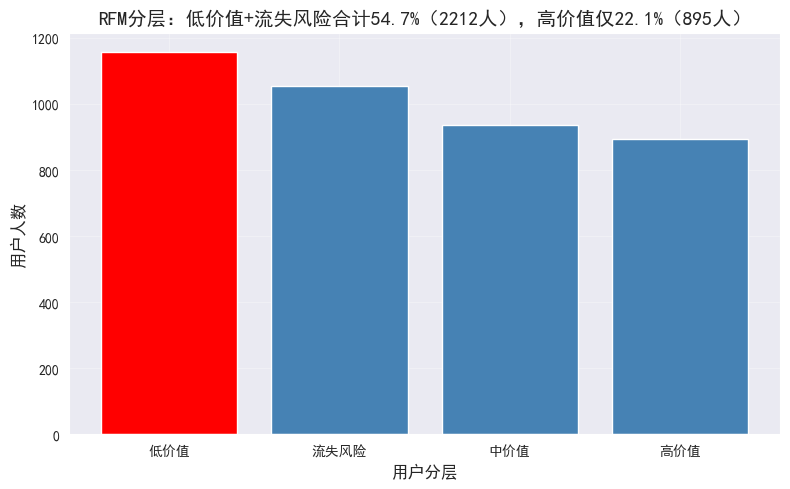

In [97]:
总人数 = len(rfm)
低价值_流失 = 分层统计['低价值'] + 分层统计['流失风险']
高价值 = 分层统计['高价值']
低流失_ratio = 低价值_流失 / 总人数 * 100
高价值_ratio = 高价值 / 总人数 * 100

title_text = f'RFM分层：低价值+流失风险合计{低流失_ratio:.1f}%（{低价值_流失}人），高价值仅{高价值_ratio:.1f}%（{高价值}人）'

plt.figure(figsize=(8,5))
plt.bar(分层统计.index,
        分层统计.values,
        color=['red' if val == 分层统计.values.max() else 'steelblue' for val in 分层统计.values])
plt.title(title_text, fontsize=14)
plt.xlabel('用户分层', fontsize=12)
plt.ylabel('用户人数', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## <a id="14"></a> 14. RFM客户分层总结

### 📊 核心结论

基于RFM模型对 **4,044名用户** 进行分层分析，结果显示：

| 客户分层 | 人数 | 占比 |
|----------|------|------|
| 高价值客户 | 895 | 22.1% |
| 中价值客户 | 937 | 23.2% |
| 低价值客户 | 1,157 | 28.6% |
| 流失风险客户 | 1,055 | 26.1% |

客户结构呈 **“底部大、顶部小”的金字塔形状**，低价值客户和流失风险客户合计占比超过 **54.7%**。

---

### 🔍 归因分析

**1. 高价值客户占比偏低**
- 高价值客户仅占22.1%
- 低于低价值客户（28.6%）和流失风险客户（26.1%）
- 说明平台的高价值用户群体**尚未形成规模**

**2. 流失风险客户占比较高**
- 超过四分之一（26.1%）的用户处于流失风险状态
- 这些用户R值低（距离上次购买时间较长）
- 存在较大的**流失隐患**

**3. 客户结构呈金字塔形**
- 从高价值到流失风险，客户占比逐层增加
- 符合电商平台的典型客户分布规律

---

### 💡 分层发现

| 分层 | 人数 | 占比 | 特征 | 状态 |
|------|------|------|------|------|
| **高价值客户** | 895 | 22.1% | R、F、M均高分 | 平台核心用户，贡献大部分销售额 |
| **中价值客户** | 937 | 23.2% | 某维度不足 | 平台中坚力量，有提升空间 |
| **低价值客户** | 1,157 | 28.6% | R值中等，F和M较低 | 低频或低消费用户 |
| **流失风险客户** | 1,055 | 26.1% | R值低（距离上次购买时间长） | 可能已经流失或即将流失 |

---

### 💡 优化建议

**1. 高价值客户重点维护**
- 建立VIP服务体系
- 提供专属客服、生日礼品、新品优先购等权益
- 目标：提升用户忠诚度，防止向中价值滑落

**2. 中价值客户向上转化**
- 针对R高F低M低的用户：推送爆款商品和组合优惠，提升购买频率
- 针对R低F高M高的用户：发送召回优惠券，唤醒购买

**3. 低价值客户激活策略**
- 分析低价值客户的购买偏好
- 通过邮件推送其感兴趣的商品
- 设置“满额包邮”等门槛
- 目标：提升客单价和复购率

**4. 流失风险客户强力召回**
- 对距离上次购买时间较长的用户
- 发送大额优惠券（如满£10减£3）
- 配合短信提醒
- 目标：争取挽回

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| **短期** | 流失风险客户占比 | 26.1% → **20%** |
|  | 召回流失用户 | 成功召回 **500名以上** |
| **中期** | 高价值客户占比 | 22.1% → **30%** |
|  | 客户结构 | 形成更健康的客户结构 |
| **长期** | RFM自动化运营体系 | 实现分层差异化触达 |
|  | 用户生命周期价值 | 持续提升LTV |

---

### 🎯 一句话总结

**高价值+中价值客户合计占45.3%，流失风险客户占26.1%，需要通过精细化运营提升高价值客户占比、挽回流失用户。**

---

In [98]:
# ==================== 第十五部分：同期群分析 ====================
# 步骤1：识别每个用户的首次购买月份
用户首次购买 = df.groupby('用户id')['订单时间'].min().reset_index()
用户首次购买.columns = ['用户id', '首次购买时间']
用户首次购买['首次购买月份'] = 用户首次购买['首次购买时间'].dt.to_period('M')

# 步骤2：合并到原数据
同期群数据 = df.merge(用户首次购买[['用户id', '首次购买月份']], on='用户id', how='left')
同期群数据['订单月份'] = 同期群数据['订单时间'].dt.to_period('M')
同期群数据['月份差'] = (同期群数据['订单月份'] - 同期群数据['首次购买月份']).apply(lambda x: x.n)

# 步骤3：构建同期群矩阵
同期群统计 = 同期群数据.groupby(['首次购买月份', '月份差'])['用户id'].nunique().reset_index()
同期群透视表 = 同期群统计.pivot(index='首次购买月份', columns='月份差', values='用户id')

# 步骤4：计算留存率
同期群基数 = 同期群透视表.iloc[:, 0]
同期群留存率 = 同期群透视表.divide(同期群基数, axis=0) * 100

print("同期群矩阵（用户数）:")
print(同期群透视表.head())
print("\n留存率矩阵（%）:")
print(round(同期群留存率.head(), 1))

同期群矩阵（用户数）:
月份差         0      1      2      3      4      5      6      7      8      9   \
首次购买月份                                                                          
2010-12  777.0  267.0  235.0  277.0  266.0  298.0  277.0  264.0  262.0  284.0   
2011-01  388.0   82.0  103.0   87.0  119.0  104.0   93.0   95.0  114.0  122.0   
2011-02  352.0   61.0   65.0   89.0   89.0   76.0   82.0   97.0   87.0  113.0   
2011-03  411.0   64.0  108.0   77.0   91.0   70.0  101.0   92.0  110.0   32.0   
2011-04  288.0   54.0   53.0   53.0   52.0   63.0   59.0   76.0   15.0    NaN   

月份差         10     11     12  
首次购买月份                        
2010-12  283.0  381.0  194.0  
2011-01  141.0   49.0    NaN  
2011-02   25.0    NaN    NaN  
2011-03    NaN    NaN    NaN  
2011-04    NaN    NaN    NaN  

留存率矩阵（%）:
月份差         0     1     2     3     4     5     6     7     8     9     10  \
首次购买月份                                                                       
2010-12  100.0  34.4  30.2  35.6  34

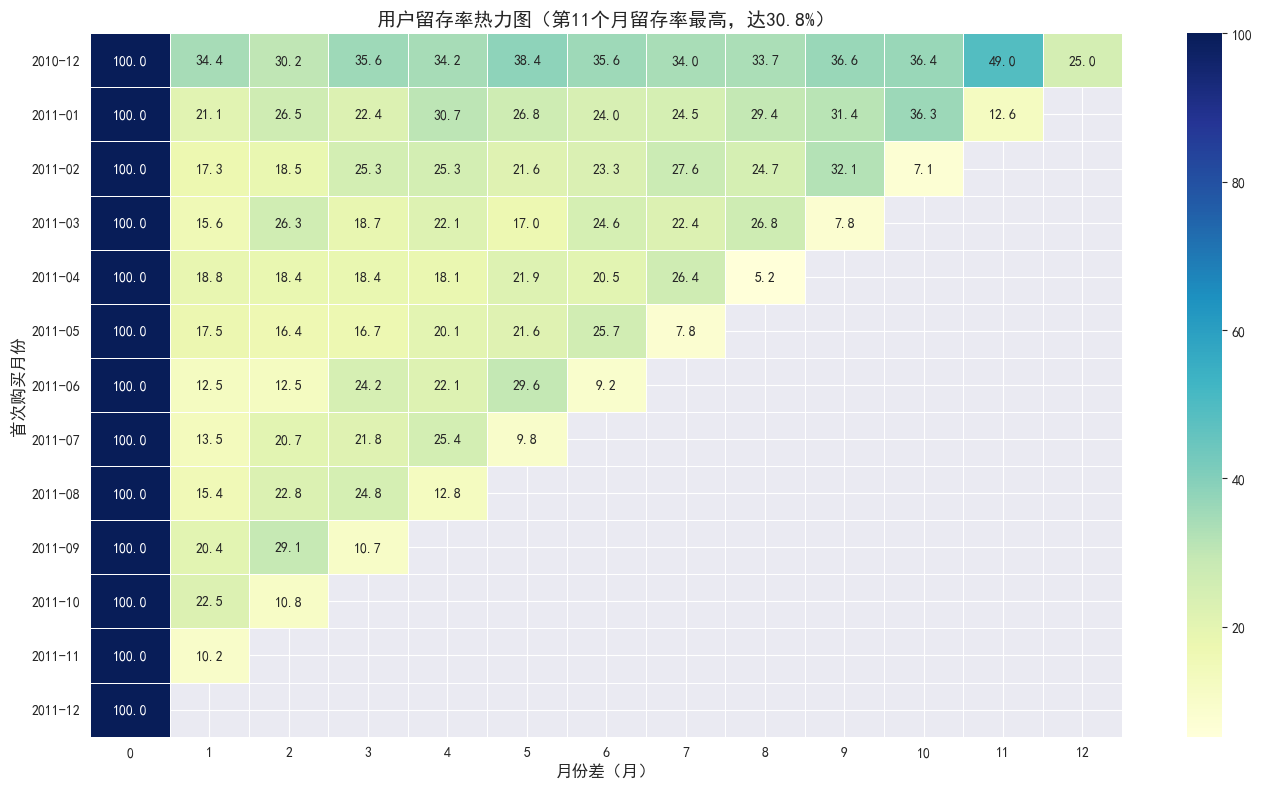


平均留存率（按月）:
月份差
0     100.0
1      18.3
2      21.1
3      21.9
4      23.4
5      23.3
6      23.3
7      23.8
8      24.0
9      27.0
10     26.6
11     30.8
12     25.0
dtype: float64


In [99]:
# 使用热力图展示
import seaborn as sns
# 去掉第0个月
平均留存 = 同期群留存率.mean()
平均留存_排除首月 = 平均留存[1:]

平均最大留存率 = round(平均留存_排除首月.max(), 1)
平均最大留存率的月份 = 平均留存_排除首月.idxmax()

plt.figure(figsize=(14, 8))
sns.heatmap(round(同期群留存率, 1),
            annot=True,
            fmt='.1f',
            cmap='YlGnBu',
            linewidths=0.5)
plt.title(f'用户留存率热力图（第{平均最大留存率的月份}个月留存率最高，达{平均最大留存率}%）', fontsize=14)
plt.xlabel('月份差（月）', fontsize=12)
plt.ylabel('首次购买月份', fontsize=12)
plt.tight_layout()
plt.show()

print("\n平均留存率（按月）:")
print(round(平均留存,1))

## <a id="15"></a> 15. 同期群分析总结

### 📊 核心结论

基于用户首次购买月份进行同期群分析，追踪各月份新用户在后期的留存情况：

| 首次购买月份 | 新增用户 | 1月留存率 | 3月留存率 | 6月留存率 | 12月留存率 |
|--------------|----------|-----------|-----------|-----------|------------|
| 2010-12 | 777人 | 34.4% | 35.6% | 35.6% | 25.0% |
| 2011-01 | 388人 | 21.1% | 22.4% | 24.0% | - |
| 2011-02 | 352人 | 17.3% | 25.3% | 23.3% | - |
| 2011-03 | 411人 | 15.6% | 18.7% | 24.6% | - |
| 2011-04 | 288人 | 18.8% | 18.4% | 20.5% | - |

**核心发现：**
- **最大新增用户群**：2010年12月（777人），为圣诞购物季效应
- **留存率表现**：各同期群1月留存率在15%-35%之间，12月留存率约25%
- **2010年12月同期群表现最优**：各月留存率稳定在30%-40%

---

### 🔍 归因分析

**1. 圣诞季用户质量更高**
- 2010年12月同期群留存率明显高于其他月份
- 原因：圣诞购物季用户购买目的明确，用户质量高

**2. 1-4月新增用户留存率偏低**
- 1月留存率仅15%-21%
- 原因：非促销期用户消费意愿较弱

**3. 留存率稳定在20%-40%**
- 无明显断崖式下跌
- 用户粘性中等，有提升空间

---

### 💡 优化建议

**1. 提升新用户首月留存**
- 新用户注册后7天内推送个性化推荐
- 设置“首购礼包”激励二次购买

**2. 针对不同同期群差异化运营**
- 圣诞季同期群：重点维护，提升忠诚度
- 淡季同期群：加大唤醒力度

**3. 优化新用户引导流程**
- 简化注册流程
- 新用户专享优惠券

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| 短期 | 1月留存率 | 提升至30%以上 |
| 中期 | 3月留存率 | 提升至35%以上 |
| 长期 | 12月留存率 | 提升至30%以上 |

---

### 🎯 一句话总结

**2010年12月圣诞季新增用户最多（777人）且留存率最高（12月留存25%），是平台获取高质量用户的关键窗口期。**

---

In [112]:
# ==================== 第十六部分：帕累托分析 ====================
# 用户维度
用户消费总额 = df.groupby('用户id')['订单总价格'].sum().sort_values(ascending=False)
累计占比 = 用户消费总额.cumsum() / 用户消费总额.sum() * 100

# 找到贡献80%销售额的用户比例
贡献80的用户数 = 累计占比[累计占比 <= 80].count()
总用户数 = len(用户消费总额)
用户占比 = 贡献80的用户数 / 总用户数 * 100

print(f"帕累托分析:用户维度")
print(f"前{贡献80的用户数}名用户（占{用户占比:.1f}%）贡献了80%的销售额")

# 商品维度
商品销量总额 = df.groupby('商品id')['购买数量'].sum().sort_values(ascending=False)
商品累计占比 = 商品销量总额.cumsum() / 商品销量总额.sum() * 100

# 找到贡献80%销量的商品比例
贡献80的商品数 = 商品累计占比[商品累计占比 <= 80].count()
商品总数 = len(商品销量总额)
商品占比 = 贡献80的商品数 / 商品总数 * 100

print(f"\n帕累托分析：商品维度")
print(f"前{贡献80的商品数}种商品（占{商品占比:.1f}%）贡献了80%的销量")

帕累托分析:用户维度
前1090名用户（占27.0%）贡献了80%的销售额

帕累托分析：商品维度
前818种商品（占25.3%）贡献了80%的销量


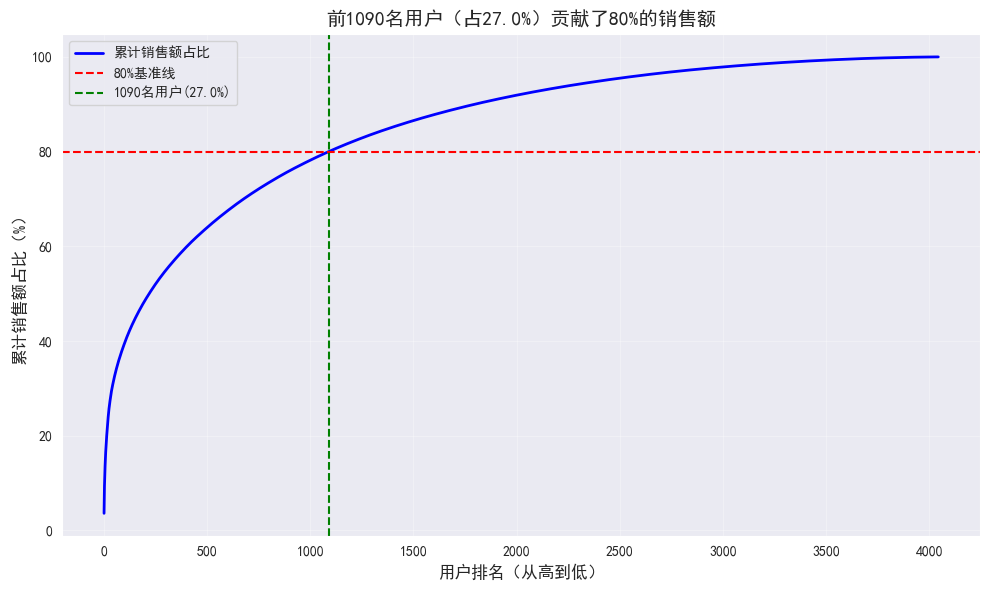

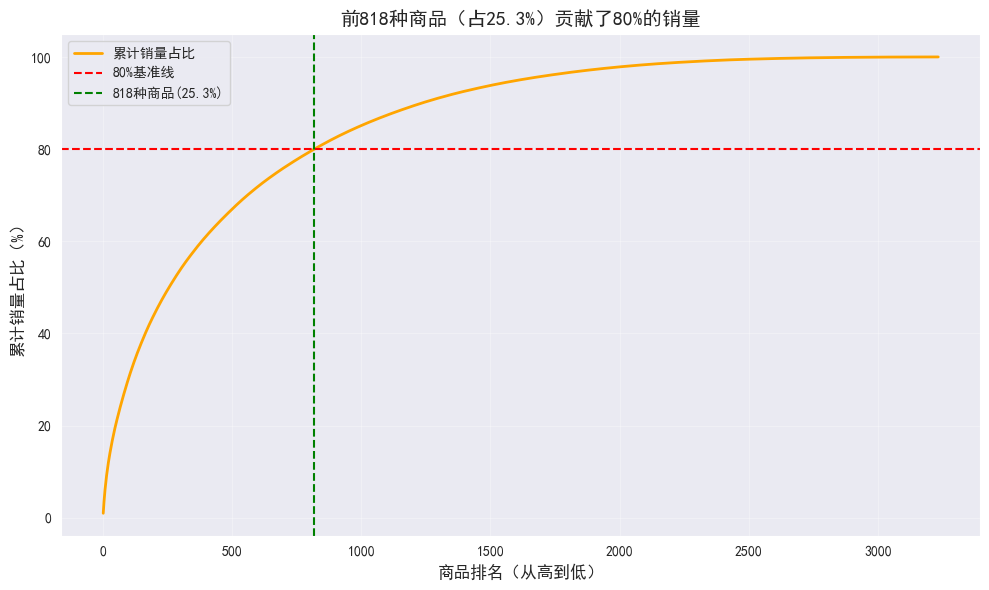

In [113]:
# 使用折线图展示,用户维度
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(range(1, len(累计占比)+1), 累计占比, color='b',
         linestyle='-', linewidth=2, label='累计销售额占比')
ax1.axhline(y=80, color='r', linestyle='--', label='80%基准线')
ax1.axvline(x=贡献80的用户数, color='g', linestyle='--', label=f'{贡献80的用户数}名用户({用户占比:.1f}%)')
ax1.set_xlabel('用户排名（从高到低）', fontsize=12)
ax1.set_ylabel('累计销售额占比（%）', fontsize=12)
ax1.set_title(f"前{贡献80的用户数}名用户（占{用户占比:.1f}%）贡献了80%的销售额", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 使用折线图展示,商品维度
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(1, len(商品累计占比)+1), 商品累计占比, color='orange',
         linestyle='-', linewidth=2, label='累计销量占比')
ax2.axhline(y=80, color='r', linestyle='--', label='80%基准线')
ax2.axvline(x=贡献80的商品数, color='g', linestyle='--', label=f'{贡献80的商品数}种商品({商品占比:.1f}%)')
ax2.set_xlabel('商品排名（从高到低）', fontsize=12)
ax2.set_ylabel('累计销量占比（%）', fontsize=12)
ax2.set_title(f"前{贡献80的商品数}种商品（占{商品占比:.1f}%）贡献了80%的销量", fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## <a id="16"></a> 16. 帕累托分析总结

### 📊 核心结论

**用户维度：**
- 前**1,090名用户**（占**27.0%**）贡献了80%的销售额
- 略高于经典的二八定律（20%用户贡献80%销售额），头部效应明显

**商品维度：**
- 前**818种商品**（占**25.3%**）贡献了80%的销量
- 接近二八定律（20%商品贡献80%销量），商品集中度较高

---

### 🔍 归因分析

**1. 用户头部效应明显**
- 27%的用户贡献80%销售额
- 高价值用户集中度较高，对平台收入影响重大

**2. 商品集中度较高**
- 25%的商品贡献80%销量
- 爆款商品对平台销量贡献显著

**3. 符合电商平台典型特征**
- 用户和商品均呈现头部集中、长尾分布的特点
- 与二八定律基本吻合

---

### 💡 优化建议

**1. 高价值用户维护（前27%）**
- 建立VIP服务体系
- 提供专属客服、生日礼品、新品优先购
- 目标：提升忠诚度，降低流失风险

**2. 潜力用户转化（剩余73%）**
- 针对中低价值用户精准营销
- 推送爆款商品和组合优惠
- 目标：提升消费金额，向高价值用户转化

**3. 爆款商品策略（前25%）**
- 确保818种核心商品库存充足
- 首页和分类页优先展示
- 目标：稳定销量基本盘

**4. 长尾商品激活（剩余75%）**
- 与爆款商品捆绑销售
- 分析潜力商品，培育新爆款
- 目标：优化商品结构，降低对单一爆款的依赖

---

### 🎯 预期目标

| 维度 | 阶段 | 目标 | 具体指标 |
|------|------|------|----------|
| 用户 | 短期 | 优化用户结构 | 前25%用户贡献80%销售额 |
|  | 中期 | 提升用户价值 | 中低价值用户客单价提升20% |
| 商品 | 短期 | 优化商品结构 | 前20%商品贡献80%销量 |
|  | 中期 | 培育新爆款 | 新增50种商品进入TOP818 |

---

### 🎯 一句话总结

**27%的核心用户贡献80%销售额，25%的爆款商品贡献80%销量，符合二八定律，需重点维护头部用户和商品。**

---

## <a id="17"></a> 17. 📌 项目总结

### 🎯 核心结论（摘要）

| 维度 | 核心发现 | 关键数据 |
|------|----------|----------|
| **用户粘性** | 复购率良好，但一次性用户占38% | 复购率 **62.3%** |
| **活跃规律** | 每月6号为活跃峰值，与发薪日相关 | 峰值 **536人** |
| **商品表现** | 85123A是销量冠军，22423是销售额冠军 | 销量8,807件 / 销售额£26,794 |
| **市场格局** | 过度依赖英国市场 | 英国占 **84.5%** |
| **客户结构** | 高价值占比低，流失风险较高 | 高价值22.1% / 流失风险26.1% |
| **用户留存** | 圣诞季用户质量最高 | 12月留存率 **25%** |
| **关联规则** | 数据稀疏，无有效关联规则 | 商品3,234种 / 订单15,193单 |

---

### 📈 各模块核心结论

**1. 新老客户分析**
- 老用户3,902人（96.5%），新用户142人（3.5%）
- 新客占比较低，获客能力有待提升

**2. 复购率分析**
- 复购率62.3%，一次性用户占37.7%
- 客单价£3.02，用户决策成本低

**3. 活跃时段分析**
- 每月6号为峰值（536人）
- 归因：英国5号发薪日 + 周末效应

**4. 订单连带率**
- 连带率79%，近八成订单含2件及以上商品

**5. 商品关联分析**
- 22697&22698组合最强（48次）
- 20725是核心关联商品（出现6次）

**6. Apriori关联规则挖掘**
- 频繁项集182个，但有效关联规则为0
- 原因：商品种类多（3,234种），订单分散，数据稀疏
- 结论：不适合Apriori算法，改用商品对共现统计更有效

**7. 商品销量排名**
- 85123A销量8,807件位居第一
- TOP3均超7,000件，头部差距不大

**8. 商品销售额排名**
- 22423销售额£26,794位居第一
- 85123A（销量第1）销售额第2，属薄利多销型

**9. 月度销售额趋势**
- 总销售额£1,503,789.51，月均£125,316
- 11月峰值£202,739.59，2月低谷£82,768.20
- 全年增长102%

**10. 国家分析**
- 英国销售额占84.5%，用户占90.2%
- 荷兰用户价值最高（销售额第2，用户数未进TOP10）

**11. RFM客户分层**
- 高价值22.1% / 中价值23.2% / 低价值28.6% / 流失风险26.1%
- 客户结构呈金字塔形

**12. 同期群分析**
- 2010年12月同期群最大（777人），留存率最高
- 1月留存率15%-35%，12月留存率约25%
- 圣诞季用户质量明显高于其他时段

**13. 帕累托分析**
- 前27%用户贡献80%销售额
- 前25%商品贡献80%销量

---

### 💡 核心运营建议

| 目标 | 策略 | 关键动作 |
|------|------|----------|
| **拉新** | 新客转化+老带新 | £0.5无门槛券 / 老带新各得优惠券 |
| **促活** | 会员日+低谷激活 | 每月6号会员日 / 25号低谷发券 |
| **提复购** | 唤醒+积分体系 | 30天未购发券 / 消费£1积1分 |
| **提连带** | 捆绑销售+关联推荐 | 22697+22698捆绑 / 购物车弹窗推荐 |
| **爆款运营** | 85123A保量+22423提GMV | 双轮驱动，分层运营 |
| **市场拓展** | 突破荷兰+德法 | 本地化选品 / 小规模广告投放 |
| **RFM运营** | 分层差异化触达 | 高价值VIP / 中价值转化 / 低价值激活 / 流失召回 |
| **留存优化** | 提升新用户首月留存 | 新用户7天内个性化推荐 / 首购礼包 |

---

### 🎯 预期目标

| 阶段 | 目标 | 具体指标 |
|------|------|----------|
| **短期** | 新客月增量 | 142人 → 200人（+40%） |
|  | 流失风险客户 | 26.1% → 20% |
|  | 2月销售额 | £82,768 → £95,000（+15%） |
|  | 1月留存率 | 提升至30%以上 |
| **中期** | 新客占比 | 3.5% → 5% |
|  | 高价值客户占比 | 22.1% → 30% |
|  | 海外销售额占比 | 15.5% → 25% |
|  | 12月留存率 | 提升至30%以上 |
| **长期** | 自动化运营体系 | RFM分层触达 + 季节性销售预测 |
|  | 市场格局 | 英国 + 欧洲 双核心 |
|  | 数据基础设施建设 | 完善用户行为追踪，支持协同过滤推荐 |

---

### 🛠 技术栈
- **Python**：Pandas（数据处理）、Matplotlib（可视化）、NumPy（数值计算）
- **分析方法**：RFM模型、帕累托分析、同期群分析、购物篮分析、用户分层、Apriori算法